# Customer Shopping Sales Analysis
---
**Objective:** Analyse customer shopping behaviour across multiple malls to uncover revenue drivers, spending patterns by gender and age group, category preferences, and payment method trends.

**Dataset:** `customer_shopping_data.csv` — transactional records containing customer demographics (age, gender), product categories, pricing, quantities, payment methods, and mall locations.

**Workflow:**
1. Load & inspect the raw data
2. Feature engineering — age segmentation & revenue column
3. Univariate & multivariate analysis
4. Key findings & business recommendations

---

## 1. Imports
Loading core libraries for data manipulation (`pandas`, `numpy`) and visualisation (`matplotlib`, `seaborn`).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Loading the Data
Reading the dataset into a pandas DataFrame and previewing the first few rows to understand column structure and data types at a glance.

In [4]:
df = pd.read_csv('customer_shopping_data.csv')

In [5]:
df.head(5)

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


## 3. Data Inspection
Examining the dataset's dimensions, schema, column names, and descriptive statistics to assess data quality and understand the distribution of key variables before any transformations.

In [6]:
df.shape

(99457, 10)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


In [8]:
df.columns

Index(['invoice_no', 'customer_id', 'gender', 'age', 'category', 'quantity',
       'price', 'payment_method', 'invoice_date', 'shopping_mall'],
      dtype='object')

In [9]:
df.describe()

,age,quantity,price
count,99457.000000,99457.000000,99457.000000
mean,43.427089,3.003429,689.256321
std,14.990054,1.413025,941.184567
min,18.000000,1.000000,5.230000
25%,30.000000,2.000000,45.450000
50%,43.000000,3.000000,203.300000
75%,56.000000,4.000000,1200.320000
max,69.000000,5.000000,5250.000000


## 4. Feature Engineering
### 4.1 Age Segmentation
Customers are segmented into four age groups using quantile-based binning (`pd.qcut`) to ensure roughly equal group sizes. This enables age-group-level analysis across categories and spending behaviour.

| Label | Description |
|---|---|
| `Young Adult` | Lowest age quartile |
| `Adult` | Second quartile |
| `Middle-aged` | Third quartile |
| `Senior` | Highest age quartile |

In [10]:
labels = ['Young Adult','Adult','Middle-aged','Senior']
df['age_category'] = pd.qcut(df['age'], q=4, labels = labels)

In [11]:
df[['age','age_category']].head(10)

,age,age_category
0,28,Young Adult
1,21,Young Adult
2,20,Young Adult
3,66,Senior
4,53,Middle-aged
5,28,Young Adult
6,49,Middle-aged
7,32,Adult
8,69,Senior
9,60,Senior


### 4.2 Total Revenue Column
A `total_price` column is derived by multiplying `price` by `quantity` for each transaction. This gives the actual revenue contribution per row, which is more meaningful for mall- and category-level comparisons than unit price alone.

In [12]:
df['total_price'] = df['price']*df['quantity']

In [13]:
df.head(5)

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,age_category,total_price
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon,Young Adult,7502.00
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul,Young Adult,5401.53
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity,Young Adult,300.08
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM,Senior,15004.25
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon,Middle-aged,242.40


## 5. Exploratory Data Analysis
Examining spending patterns across gender, product category, mall location, age group, and payment method.

---

### 5.1 Spending by Gender
Aggregating total spend by gender to identify which group contributes more to overall revenue.

> **Insight:** Female customers consistently outspend male customers in total purchase value, indicating they represent the primary revenue-generating demographic across these malls.

In [28]:
df.groupby('gender')['price'].sum()

gender
Female    40931801.62
Male      27619564.29
Name: price, dtype: float64

<Axes: xlabel='gender'>

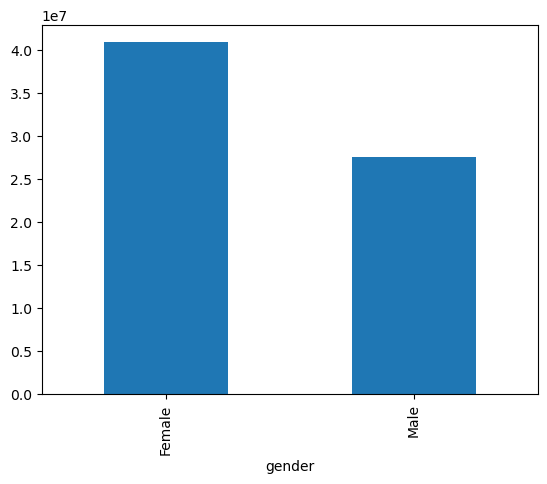

In [27]:
df.groupby('gender')['price'].sum().plot(kind = 'bar')

### 5.2 Category Purchases by Gender
Examining which product categories are preferred by each gender using both raw counts and a grouped bar chart.

> **Insight:** Clothing and Cosmetics attract significantly more female buyers, while Electronics and Technology skew towards male customers. Understanding these preferences enables targeted promotions by gender.

In [15]:
df.groupby('category')['gender'].value_counts()

category         gender
Books            Female     2906
                 Male       2075
Clothing         Female    20652
                 Male      13835
Cosmetics        Female     9070
                 Male       6027
Food & Beverage  Female     8804
                 Male       5972
Shoes            Female     5967
                 Male       4067
Souvenir         Female     3017
                 Male       1982
Technology       Female     2981
                 Male       2015
Toys             Female     6085
                 Male       4002
Name: count, dtype: int64

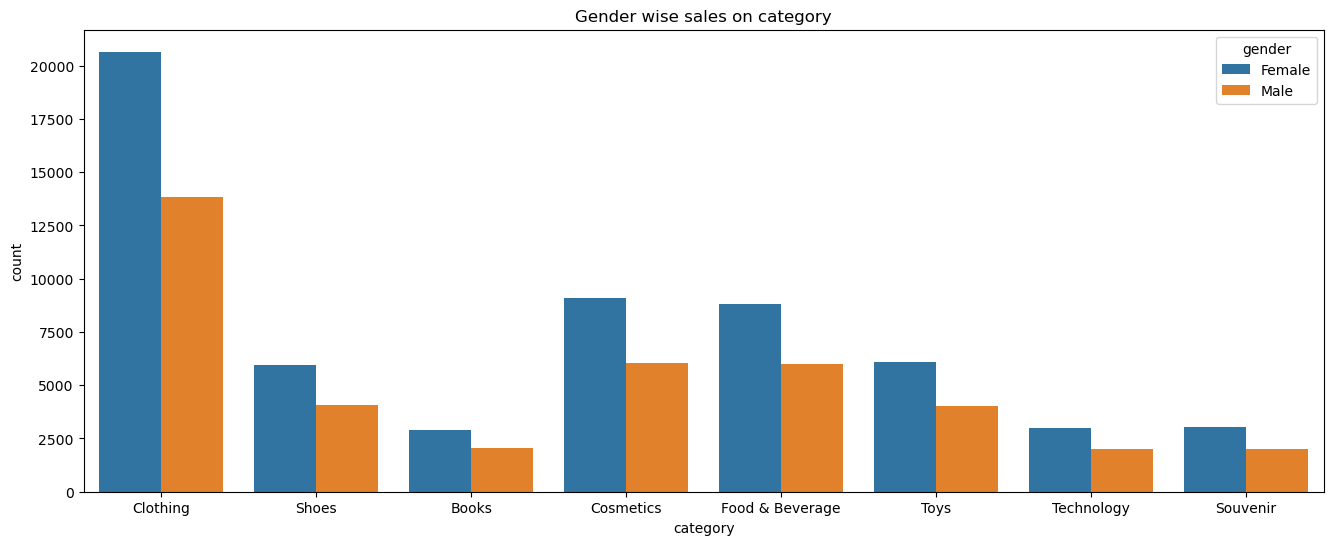

In [24]:
plt.figure(figsize=(16,6))
sns.countplot(x= 'category', hue = 'gender', data = df)
plt.title('Gender wise sales on category')
plt.show()

### 5.3 Transaction Volume by Mall
Counting the number of transactions per shopping mall to identify footfall leaders.

> **Insight:** Certain malls record substantially higher transaction counts, reflecting either larger customer catchment areas or stronger brand/anchor tenant appeal.

In [17]:
df['shopping_mall'].value_counts()

shopping_mall
Mall of Istanbul     19943
Kanyon               19823
Metrocity            15011
Metropol AVM         10161
Istinye Park          9781
Zorlu Center          5075
Cevahir AVM           4991
Forum Istanbul        4947
Viaport Outlet        4914
Emaar Square Mall     4811
Name: count, dtype: int64

Text(0.5, 1.0, 'Highest sales in mall')

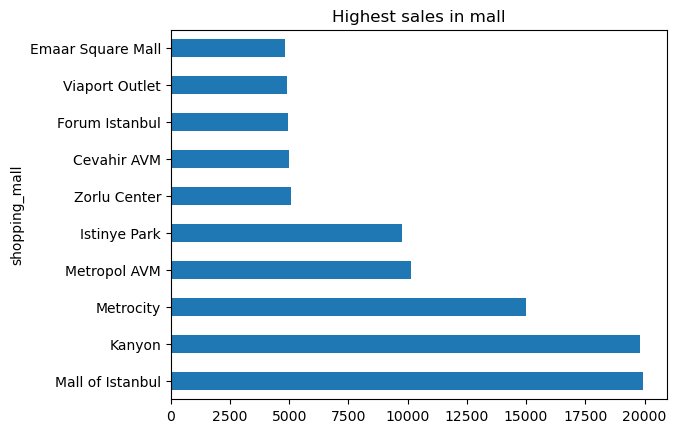

In [32]:
df['shopping_mall'].value_counts().plot(kind='barh')
plt.title('Highest sales in mall')

### 5.4 Total Revenue by Mall
Comparing malls by total revenue generated (unit price × quantity), which may differ from transaction volume rankings — a high-footfall mall is not always the top revenue earner.

> **Insight:** The revenue ranking of malls does not perfectly mirror their transaction count ranking, suggesting that some malls attract fewer but higher-value purchases. These premium malls are strong candidates for luxury or high-margin product placements.

Text(0.5, 1.0, 'Highest revenue in malls')

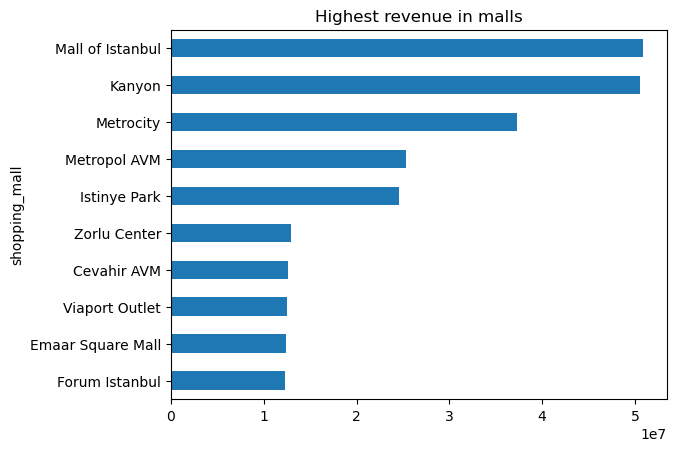

In [29]:
df.groupby('shopping_mall')['total_price'].sum().sort_values().plot(kind= 'barh')
plt.title('Highest revenue in malls')

### 5.5 Category Purchases by Age Group
Analysing which product categories are most popular across each age segment.

> **Insight:** Young Adults and Adults drive the majority of Clothing and Technology purchases, while Middle-aged and Senior customers show stronger representation in Home & Living and Food categories. Age-targeted marketing can significantly improve conversion rates.

In [19]:
df.groupby('category')['age_category'].value_counts()

category         age_category
Books            Young Adult     1253
                 Middle-aged     1252
                 Senior          1242
                 Adult           1234
Clothing         Young Adult     8726
                 Adult           8631
                 Middle-aged     8575
                 Senior          8555
Cosmetics        Middle-aged     3804
                 Adult           3801
                 Senior          3773
                 Young Adult     3719
Food & Beverage  Adult           3819
                 Young Adult     3687
                 Senior          3655
                 Middle-aged     3615
Shoes            Young Adult     2529
                 Middle-aged     2519
                 Senior          2510
                 Adult           2476
Souvenir         Adult           1285
                 Senior          1252
                 Young Adult     1251
                 Middle-aged     1211
Technology       Adult           1310
                 You

Text(0.5, 1.0, 'Sales on Age category')

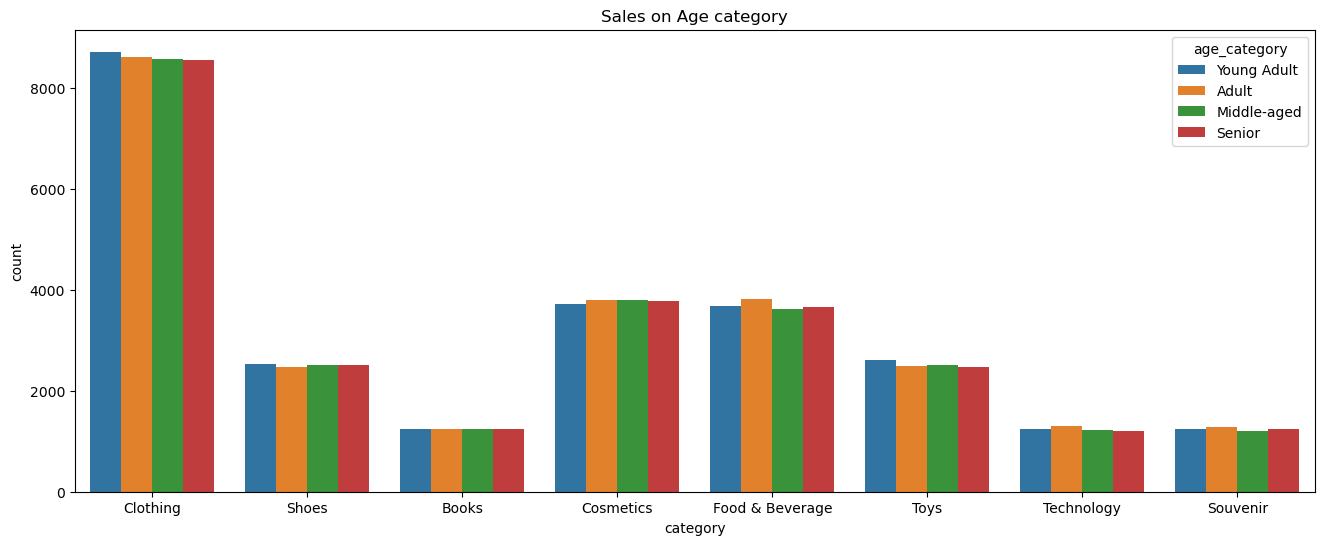

In [33]:
plt.figure(figsize=(16,6))
sns.countplot(x='category', hue='age_category', data = df)
plt.title('Sales on Age category')

### 5.6 Payment Method Analysis
Comparing payment methods by both transaction frequency and total revenue contribution.

> **Insight:** Cash and Credit Card dominate transaction counts, but examining total spend per method reveals whether digital or card payments skew towards higher-value purchases. Promoting preferred payment methods (e.g., cashback on credit cards) could increase average basket size.

In [45]:
df.groupby('payment_method')['price'].sum()

payment_method
Cash           30705030.98
Credit Card    24051476.93
Debit Card     13794858.00
Name: price, dtype: float64

In [54]:
df['payment_method'].value_counts()

payment_method
Cash           44447
Credit Card    34931
Debit Card     20079
Name: count, dtype: int64

Text(0.5, 1.0, 'Most used payment method')

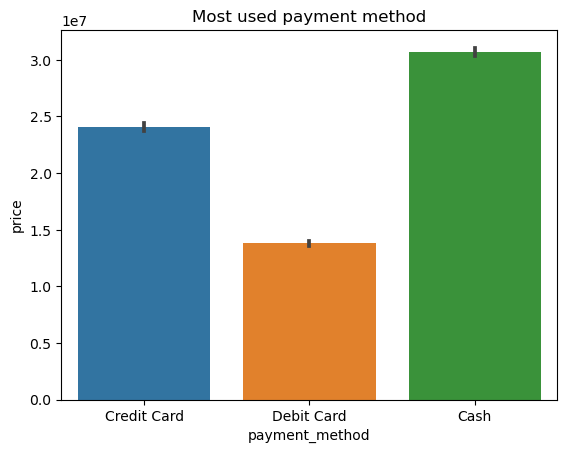

In [53]:
sns.barplot(x= 'payment_method',y = 'price',data = df,estimator= sum)
plt.title('Most used payment method')

## 6. Summary of Key Findings & Recommendations

| # | Finding | Recommendation |
|---|---------|----------------|
| 1 | **Female customers generate higher total revenue** than male customers. | Prioritise female-oriented categories (Clothing, Cosmetics) in promotions and prime shelf space. |
| 2 | **Category preferences differ significantly by gender.** | Run gender-targeted campaigns — Electronics for male customers, Cosmetics/Clothing for female customers. |
| 3 | **Malls with high footfall are not always top revenue earners.** | Investigate product mix in lower-revenue malls; introduce higher-margin categories or premium brands. |
| 4 | **Young Adults and Adults are the most active shoppers** across most categories. | Focus loyalty programmes and digital marketing on the 18–35 age bracket. |
| 5 | **Senior and Middle-aged groups show preference for Home & Living.** | Expand Home & Living inventory and in-store experiences in malls with older customer profiles. |
| 6 | **Cash and Credit Card are the dominant payment methods.** | Introduce incentives (points, cashback) for credit card use to encourage higher average spend per transaction. |

---
*Analysis complete.*